In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

### Imports

In [2]:
import os, glob
import random
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

SEED = 23455
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

### Loading Data

In [3]:
DATA_ROOT = "/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup"
STEMS_DIR = os.path.join(DATA_ROOT, "genres_stems")
NOISE_DIR = os.path.join(DATA_ROOT, "ESC-50-master", "audio")
TEST_DIR = os.path.join(DATA_ROOT, "mashups")
TEST_CSV = os.path.join(DATA_ROOT, "test.csv")
NOISE_CSV = os.path.join(DATA_ROOT, "ESC-50-master", "meta", "esc50.csv")

GENRES = sorted(['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock'])
STEMS = ['drums', "vocals", "bass", "other"]
SR = 22050 # Sample rate of audio

### Dataset Overview

In [4]:
rows = []
for genre in GENRES:
    gp = os.path.join(STEMS_DIR, genre)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for song in songs:
        for st in STEMS:
            exists = os.path.exists(os.path.join(gp, song, f"{st}.wav"))
            rows.append({
                "genre": genre,
                "song": song,
                "stem": st,
                "exists": exists
            })

df = pd.DataFrame(rows)
missing = df[~df["exists"]]

test_files = glob.glob(os.path.join(TEST_DIR, "*.wav"))
esc_meta = pd.read_csv(NOISE_CSV)

print(f"Training {df.groupby("genre")["song"].nunique().iloc[0]} songs x {len(GENRES)} genres = {df['song'].nunique()} songs")
print(f"Stems per song: {STEMS}")
print(f"Missing stems: {len(missing)} ({missing['stem'].value_counts().to_dict()})")
print(f"Test Mashups: {len(test_files)}")
print(f"ESC-50 noise: {len(esc_meta)} clips, {esc_meta['category'].nunique()} categories")

Training 100 songs x 10 genres = 1000 songs
Stems per song: ['drums', 'vocals', 'bass', 'other']
Missing stems: 0 ({})
Test Mashups: 3020
ESC-50 noise: 2000 clips, 50 categories


### Class Distribution

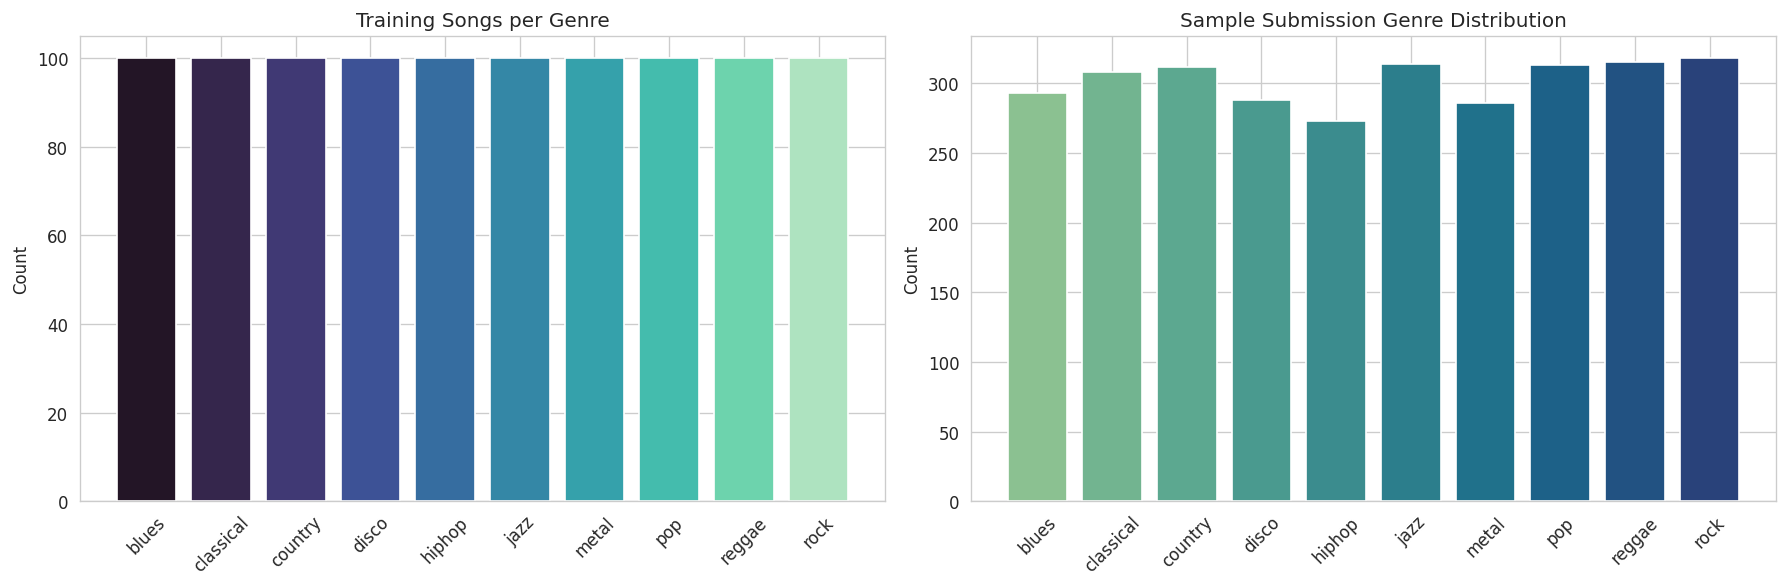

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Train
songs_per_genre = df.groupby("genre")['song'].nunique()
axes[0].bar(songs_per_genre.index, songs_per_genre.values, color=sns.color_palette("mako", 10))
axes[0].set_title('Training Songs per Genre')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Test (from sample submission)
sample_sub = pd.read_csv(os.path.join(DATA_ROOT, 'sample_submission.csv'))
test_dist = sample_sub['genre'].value_counts().sort_index()
axes[1].bar(test_dist.index, test_dist.values, color=sns.color_palette('crest', 10))
axes[1].set_title('Sample Submission Genre Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

### Raw Audioforms

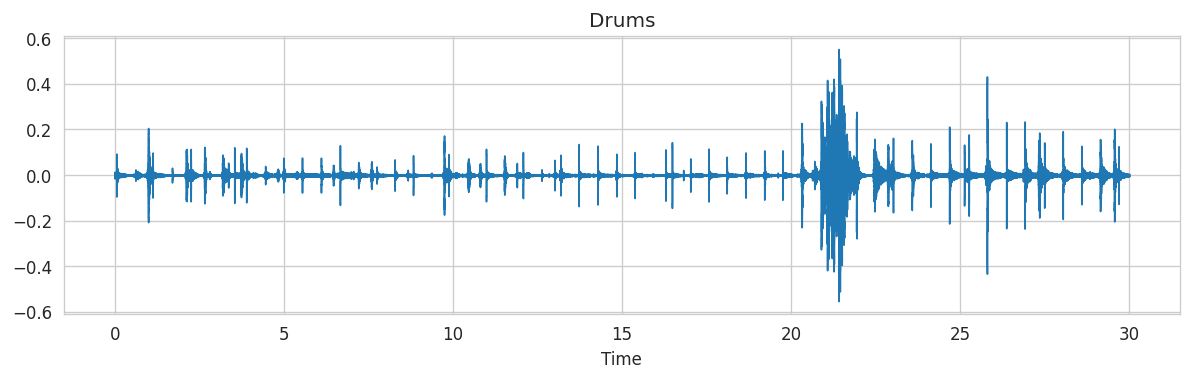

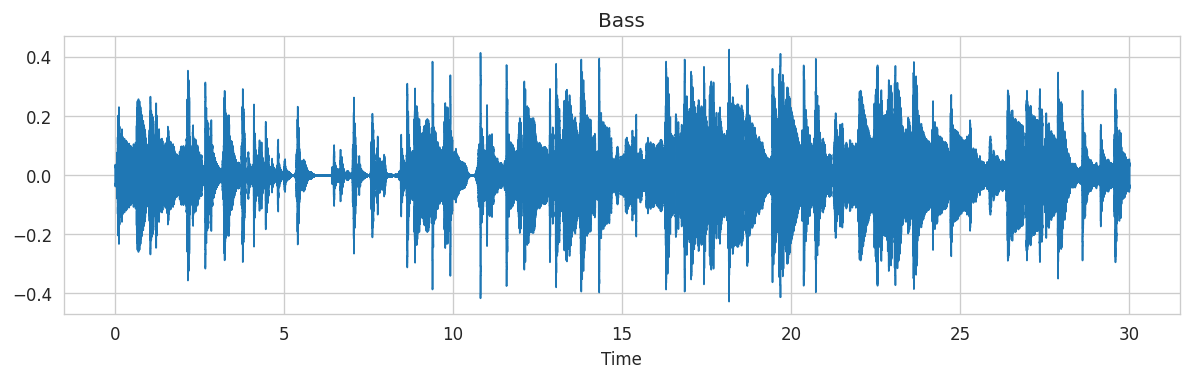

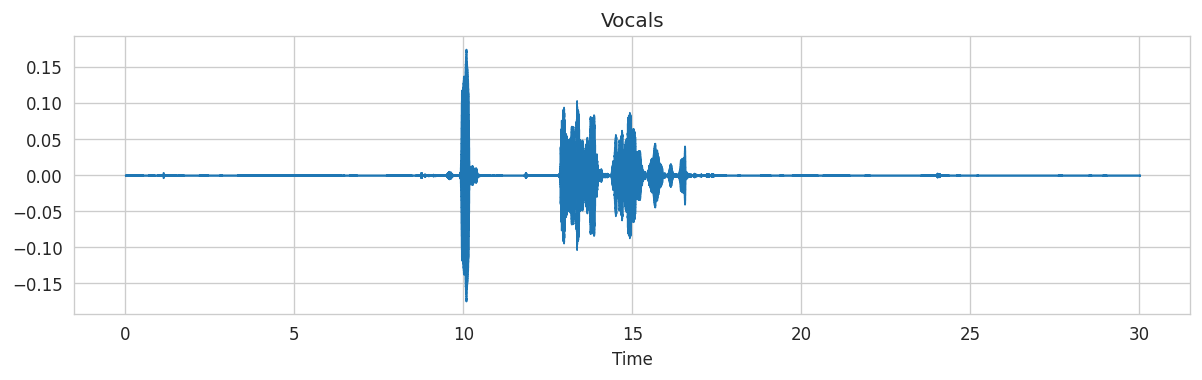

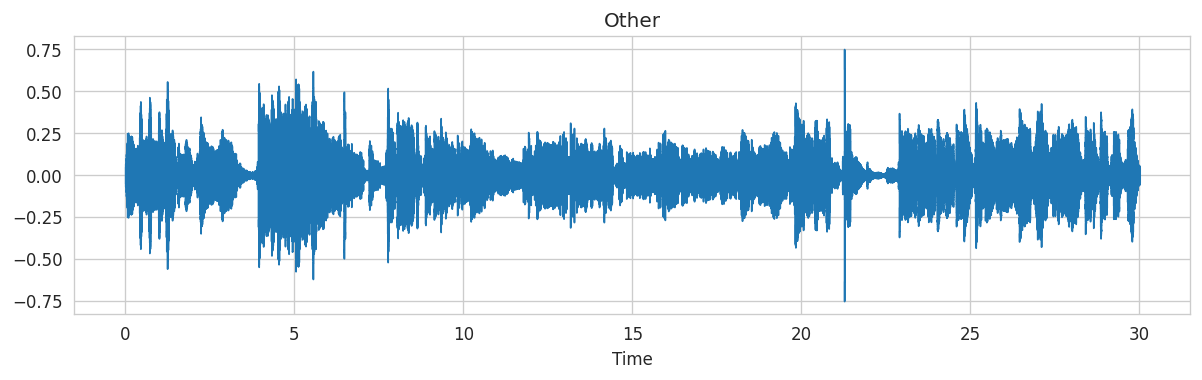

<Figure size 768x576 with 0 Axes>

In [22]:
def plot_waveform(path, title="Waveform"):
    y, sr = librosa.load(path, sr=22050)
    
    plt.figure(figsize=(12,3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title)
    plt.show()

sample = df.sample(1).iloc[0]

drums_path = os.path.join(STEMS_DIR, sample.genre, sample.song, "drums.wav")
bass_path = os.path.join(STEMS_DIR, sample.genre, sample.song, "bass.wav")
vocals_path = os.path.join(STEMS_DIR, sample.genre, sample.song, "vocals.wav")
other_path = os.path.join(STEMS_DIR, sample.genre, sample.song, "other.wav")

plot_waveform(drums_path, "Drums")
plot_waveform(bass_path, "Bass")
plot_waveform(vocals_path, "Vocals")
plot_waveform(other_path, "Other")

plt.savefig('raw_waveforms.png', bbox_inches='tight')
plt.show()

`sr` --> Sampling Rate - It tells us how fast those snapshots were taken
  - The number of data points captured in exactly one second of audio

### Audio Statistics per Genre

In [6]:
stats = []
for genre in GENRES:
    gp = os.path.join(STEMS_DIR, genre)
    songs = sorted(os.listdir(gp))[:20] # sample 20 songs
    for song in songs:
        song_dir = os.path.join(gp, song)
        if not os.path.isdir(song_dir): continue
        for st in STEMS:
            fp = os.path.join(song_dir, f"{st}.wav")
            if not os.path.exists(fp): continue
            y, _ = librosa.load(fp, sr=SR, duration=10.0)
            rms = float(np.mean(librosa.feature.rms(y=y)))
            sc = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=SR)))
            zcr = float(np.mean(librosa.feature.zero_crossing_rate(y)))
            stats.append({
                "genre": genre,
                "stem": st,
                "rms": rms,
                "spectral_centroid": sc,
                "zcr": zcr
            })


stats_df = pd.DataFrame(stats)
print(f"Computed stats for {len(stats_df)} stem files")

Computed stats for 800 stem files


`rms` --> Root Mean Square = (Loudness / Energy)
  - It is a mathematical way of calculating the average power of the audio signal over a period of time. Simply, **It meausres how *loud* the audio is.**

`sc` --> Spectral Centroid = (Brightness / Tone Color)
  - The spectral centroid finds the **"center of mass"** of the sound's frequencies. It tells you where the majority of the sound's energy is focused
  - It basically measures how **"bright"** or **"dark"** a sound is.

`zcr` --> Zero-Crossing Rate = (Noisiness / Percussiveness)
  - Sound waves constantly fluctuate up and down (positive and negative).
  - The zero-crossing rate measures exactly how many times the sound wave crosses the "zero" line in a given amount of time.
  - It measures how **noisy, scratchy, or percussive** a sound is.

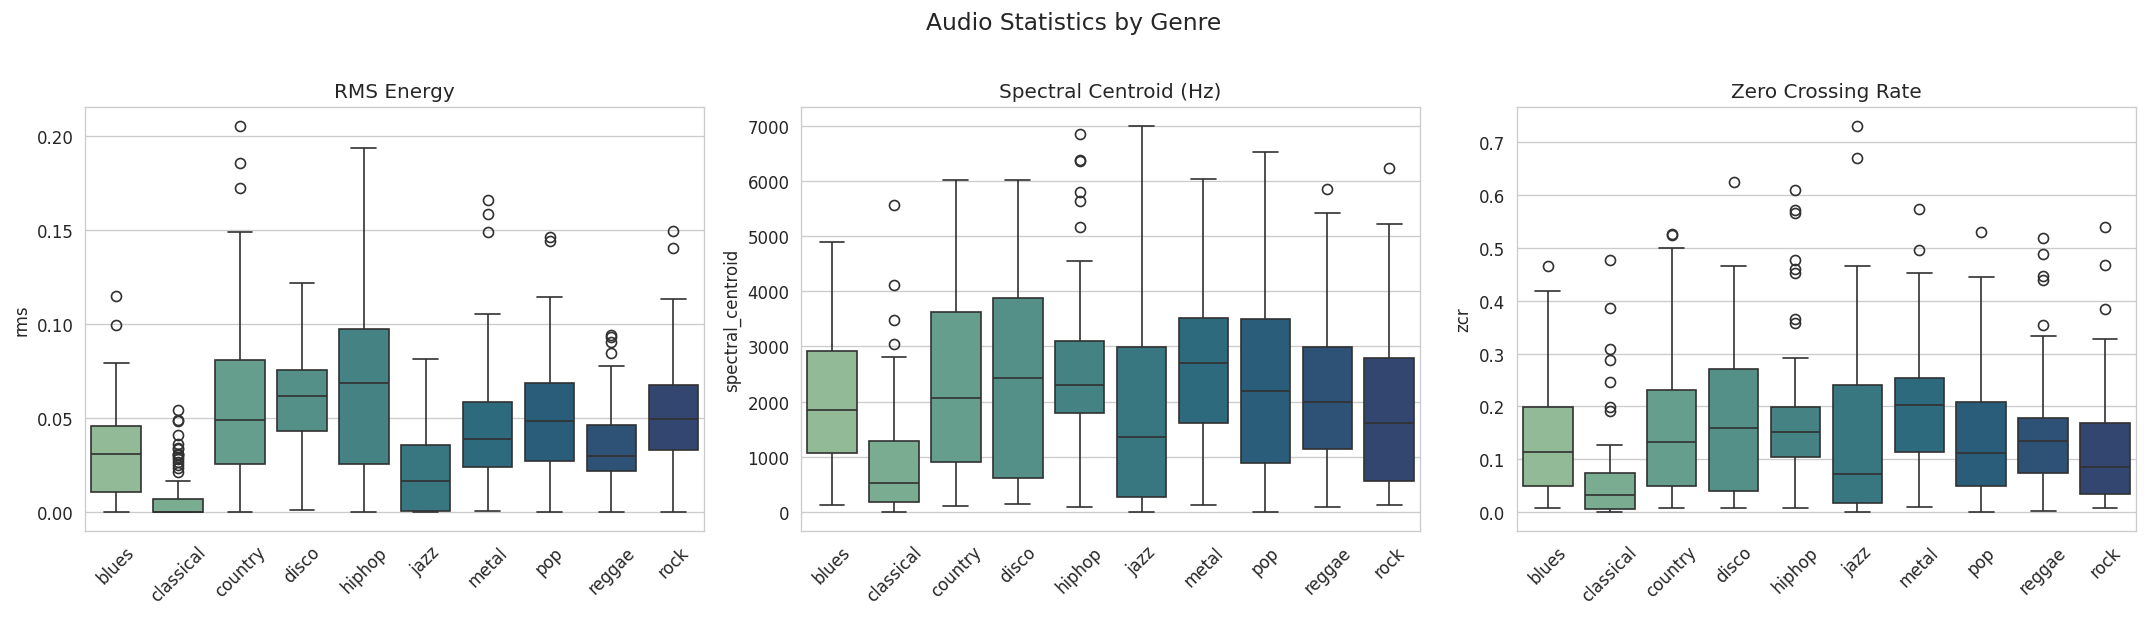

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col, title) in enumerate([('rms', 'RMS Energy'), ('spectral_centroid', 'Spectral Centroid (Hz)'), ('zcr', 'Zero Crossing Rate')]):
    sns.boxplot(data=stats_df, x='genre', y=col, ax=axes[i], palette='crest')
    axes[i].set_title(title)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
plt.suptitle('Audio Statistics by Genre', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('audio_stats_boxplot.png', bbox_inches='tight')
plt.show()

### Per Stem Genre Profiles

Can we distinguish genres with stems ?

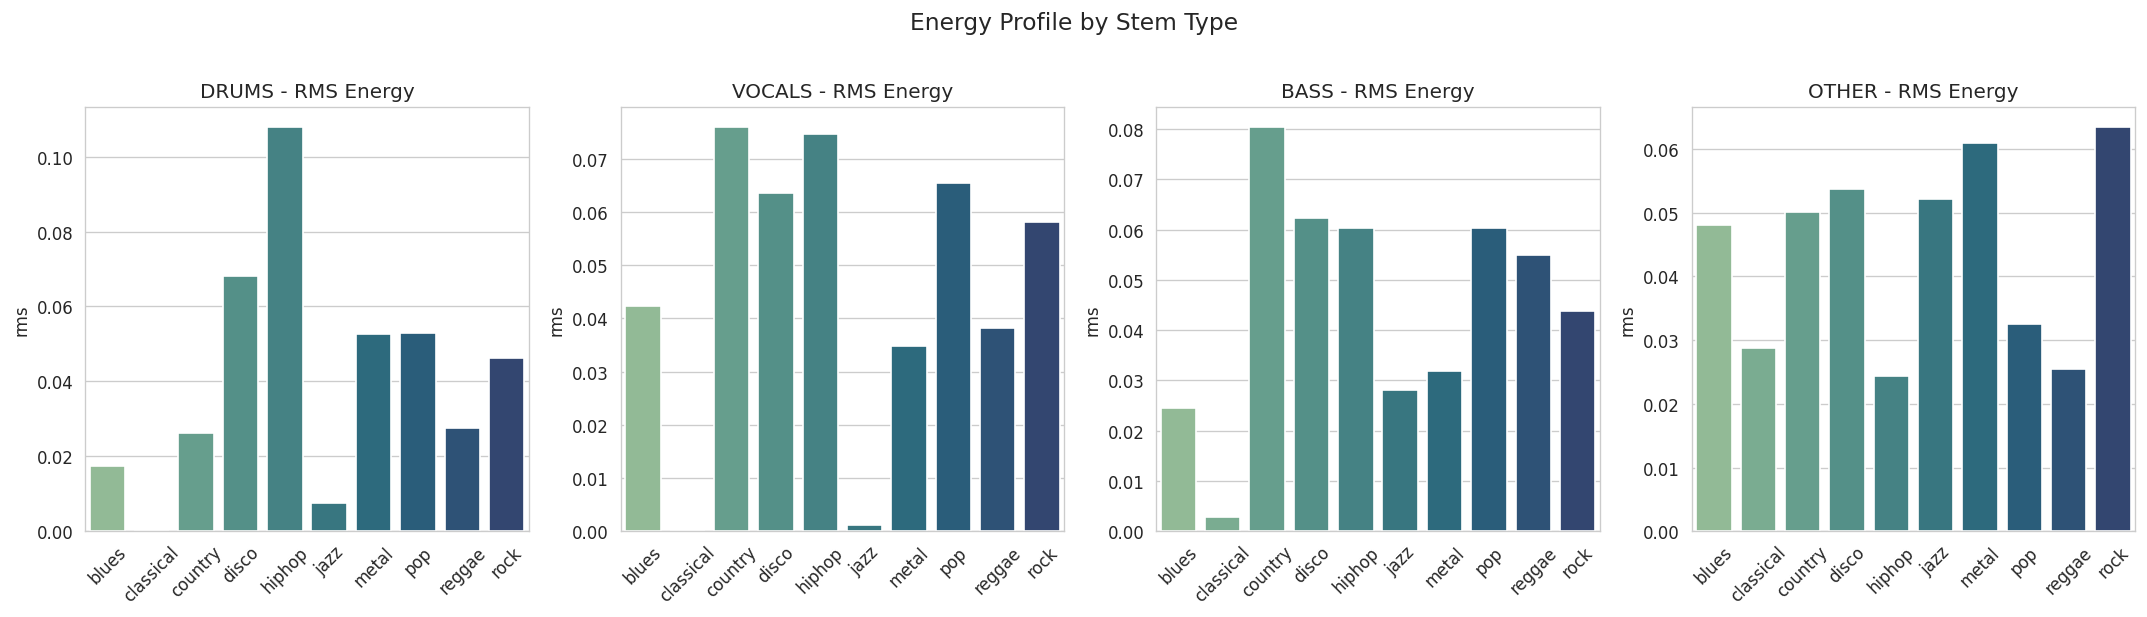

Key finding: Classical/Jazz have very low energy - model must be volume-invariant.


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, st in enumerate(STEMS):
    sub = stats_df[stats_df['stem'] == st]
    sns.barplot(data=sub, x='genre', y='rms', ax=axes[i], palette='crest', ci=None)
    axes[i].set_title(f'{st.upper()} - RMS Energy')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.suptitle("Energy Profile by Stem Type", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('stem_profiles.png', bbox_inches='tight')
plt.show()
print("Key finding: Classical/Jazz have very low energy - model must be volume-invariant.")

### Mel-Spectrograms - Train vs Test

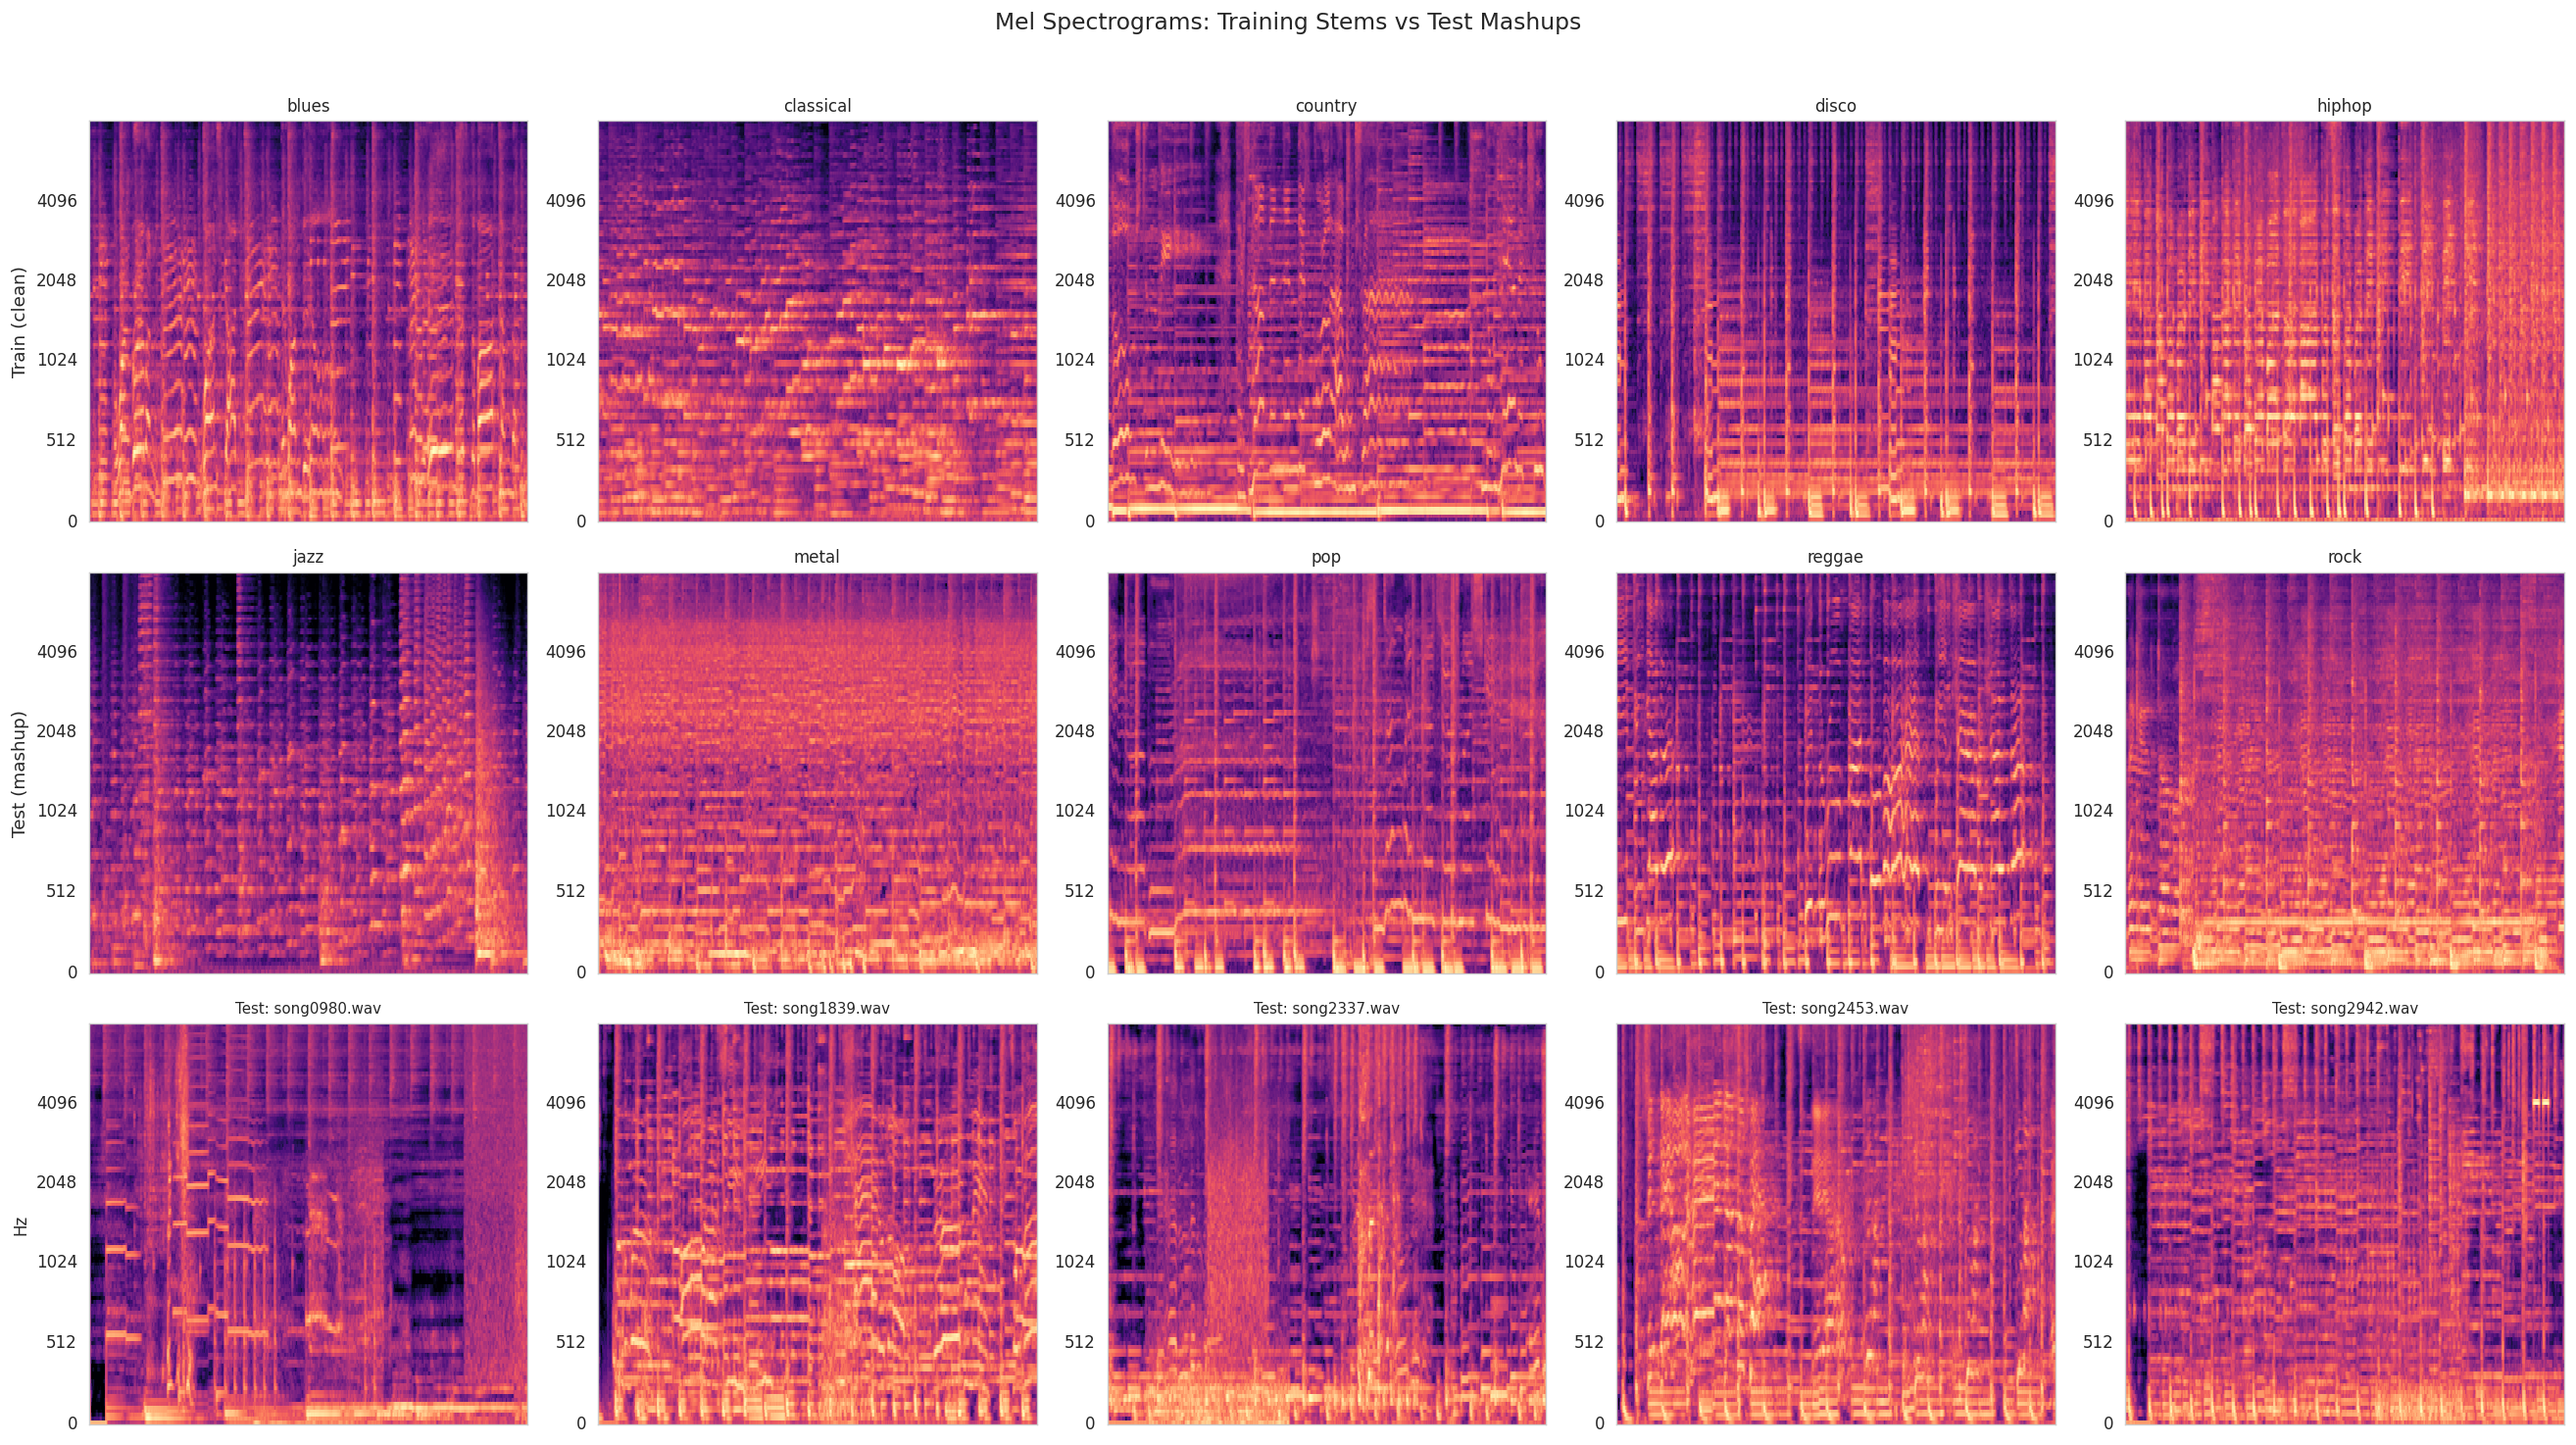

Visual domain shift: test mashups are denser, noisier, with overlapping frequency content.


In [14]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))

# row 1-2: One song per genre (mixed stemming)
for idx , genre in enumerate(GENRES):
    ax = axes[idx // 5][idx % 5]
    gp = os.path.join(STEMS_DIR, genre)
    song = sorted(os.listdir(gp))[0]
    stems_y = []
    for st in STEMS:
        fp = os.path.join(gp, song, f"{st}.wav")
        if os.path.exists(fp):
            y, _ = librosa.load(fp, sr=SR, duration=10.0)
            stems_y.append(y)

    if stems_y:
        mx = max(len(s) for s in stems_y)
        mix = np.zeros(mx)
        for s in stems_y:
            mix[:len(s)] += s
        peak = np.max(np.abs(mix))
        if peak > 0:
            mix /= peak
        S = librosa.feature.melspectrogram(y=mix, sr=SR, n_mels=128, fmax=8000)
        librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=SR, ax=ax, y_axis='mel', fmax=8000)

    ax.set_title(genre, fontsize=10)
    if idx > 0:
        ax.set_ylabel('')

# Row 2: Test mashups
test_sample = random.sample(glob.glob(os.path.join(TEST_DIR, '*.wav')), 5)
for idx, tf in enumerate(sorted(test_sample)):
    ax = axes[2][idx]
    y, _ = librosa.load(tf, sr=SR, duration=10.0)
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128, fmax=8000)
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=SR, ax=ax, y_axis='mel', fmax=8000)
    ax.set_title(f'Test: {os.path.basename(tf)[:15]}', fontsize=9)
    if idx > 0: ax.set_ylabel('')

axes[0][0].set_ylabel('Train (clean)', fontsize=11)
axes[1][0].set_ylabel('Test (mashup)', fontsize=11)
plt.suptitle('Mel Spectrograms: Training Stems vs Test Mashups', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('mel_spectrograms.png', bbox_inches='tight')
plt.show()
print("Visual domain shift: test mashups are denser, noisier, with overlapping frequency content.")

### Train vs Test Distribution Shift

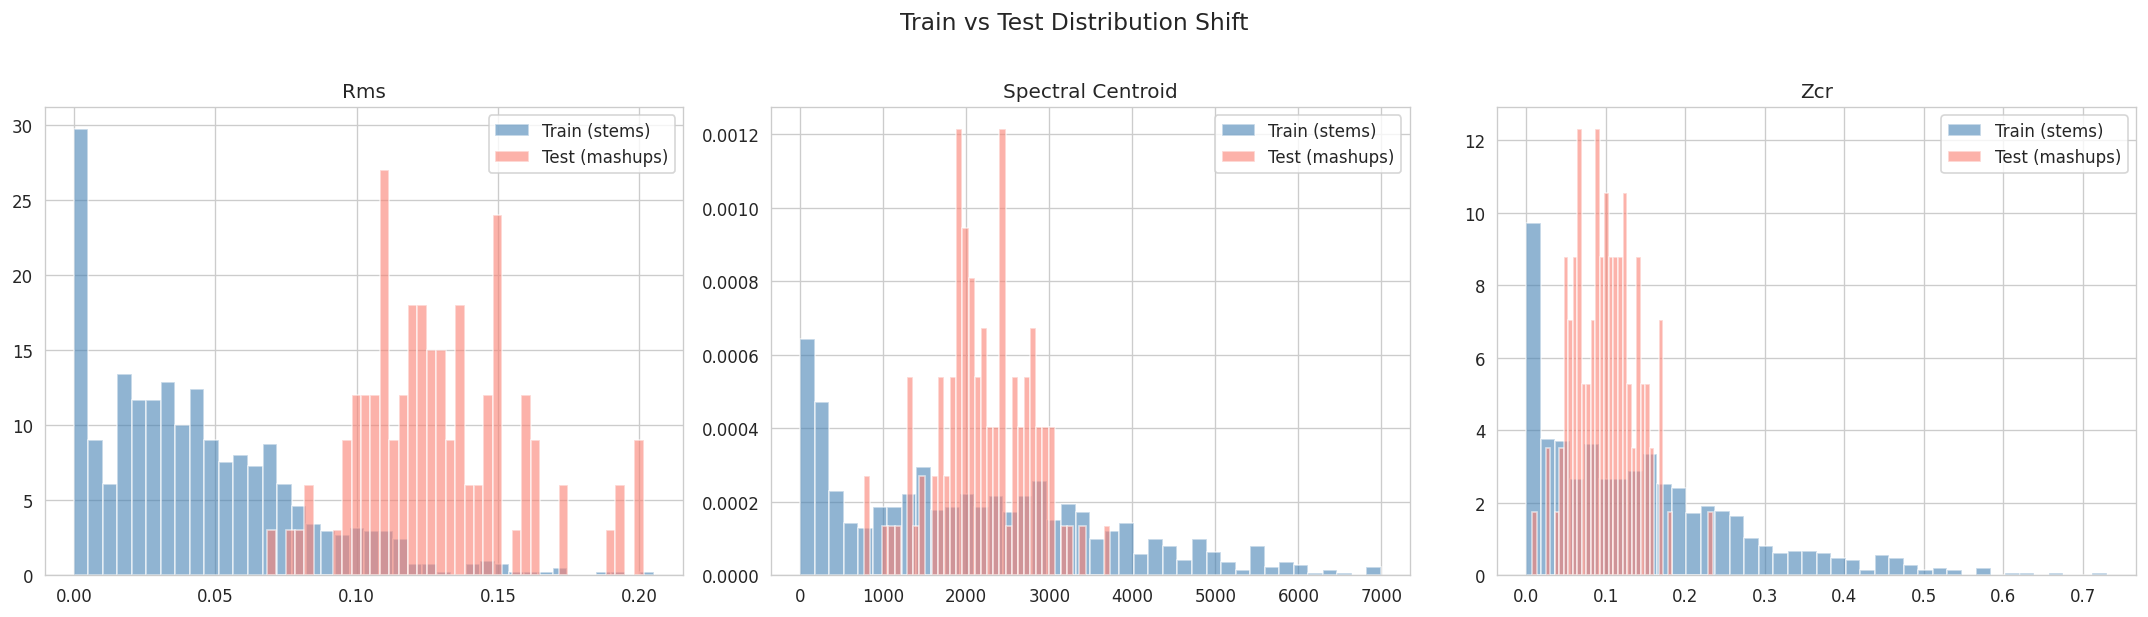

Test mashups are louder (higher RMS), denser (higher spectral centroid), confirming distribution shift.


In [15]:
# Compute stats for test samples
test_stats = []
for tf in random.sample(glob.glob(os.path.join(TEST_DIR, '*.wav')), 100):
    y, _ = librosa.load(tf, sr=SR, duration=10.0)
    test_stats.append({
        'rms': float(np.mean(librosa.feature.rms(y=y))),
        'spectral_centroid': float(np.mean(librosa.feature.spectral_centroid(y=y, sr=SR))),
        'zcr': float(np.mean(librosa.feature.zero_crossing_rate(y)))
    })
test_df = pd.DataFrame(test_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['rms', 'spectral_centroid', 'zcr']):
    axes[i].hist(stats_df[col], bins=40, alpha=0.6, density=True, label='Train (stems)', color='steelblue')
    axes[i].hist(test_df[col], bins=40, alpha=0.6, density=True, label='Test (mashups)', color='salmon')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend()
plt.suptitle('Train vs Test Distribution Shift', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('distribution_shift.png', bbox_inches='tight')
plt.show()
print("Test mashups are louder (higher RMS), denser (higher spectral centroid), confirming distribution shift.")

### ESC-50 Categories

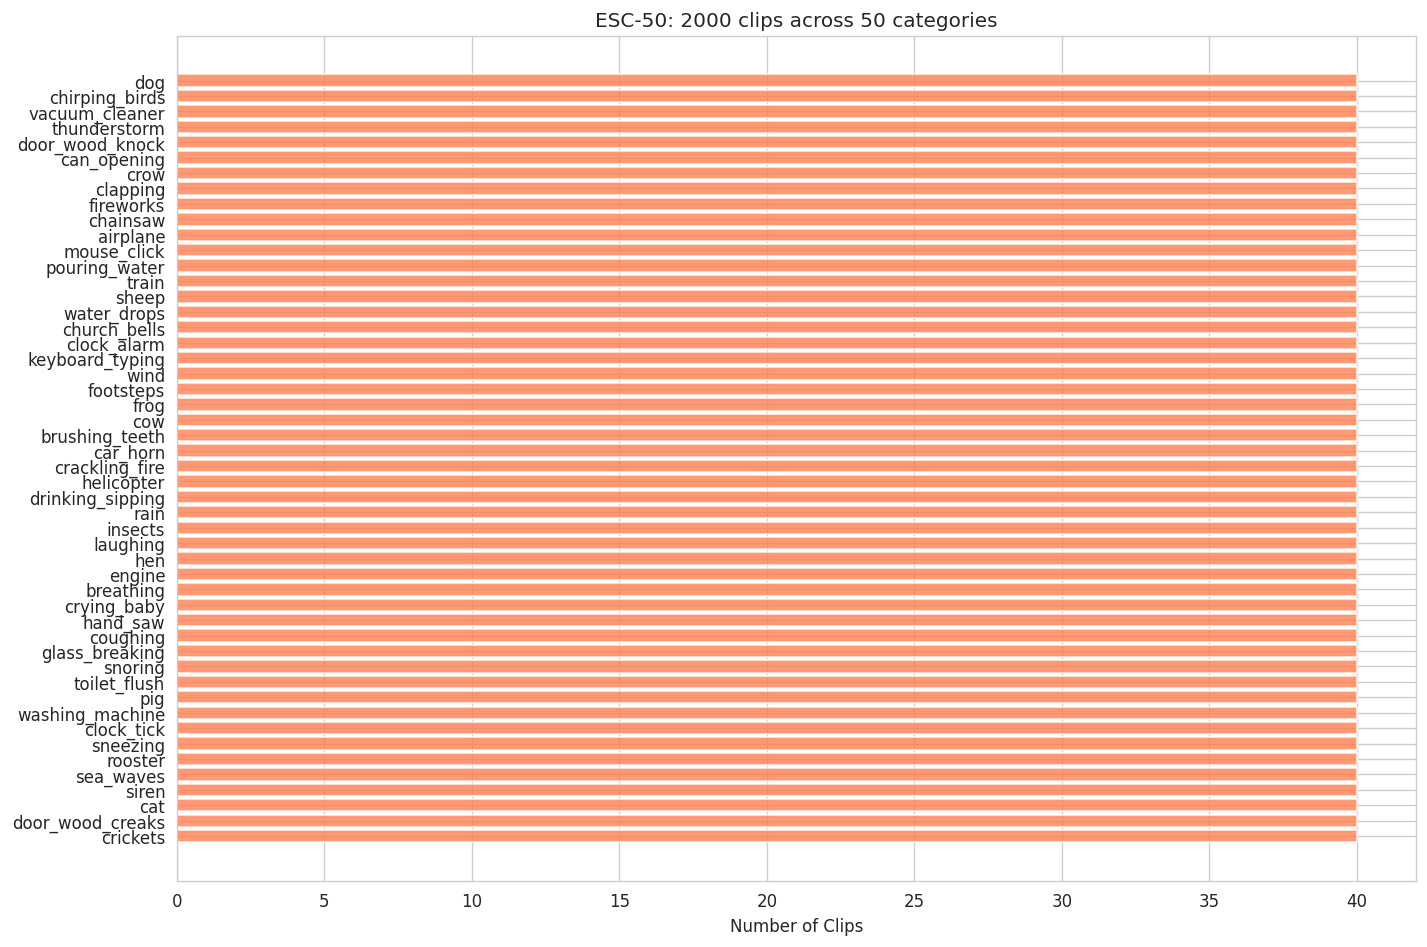

In [16]:
fig, ax = plt.subplots(figsize=(12, 8))
cat_counts = esc_meta['category'].value_counts()
ax.barh(cat_counts.index, cat_counts.values, color='coral', alpha=0.8)
ax.set_xlabel('Number of Clips')
ax.set_title(f'ESC-50: {len(esc_meta)} clips across {esc_meta["category"].nunique()} categories')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('esc50_categories.png', bbox_inches='tight')
plt.show()